In [5]:
import pandas as pd
pd.options.mode.chained_assignment = None  # get rid of SettingWithCopywarning
import numpy as np
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import re
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

rand_seed = 42

In [6]:
df_interruptions_labeled  = pd.read_csv('../_data/interruptions_labeled.csv')
df_interruptions_labeled = df_interruptions_labeled.rename(columns={'sentiment': 'label', 'comment_text':'text'})
df_interruptions_labeled.sample(5, random_state=rand_seed)

,Unnamed: 0,text,comment_party,comment_name,interrupted_speaker_party,interrupted_speaker,date,speech_id,preceding_context,label
2323,2323,Das gehört zur Landespolizei!,CDU/CSU,Max Straubinger,GRÜNE,Katrin Göring-Eckardt,2016-01-13,136027,"rren. Es kommt darauf an, dass wir klarmachen:...",0
3686,337786,Das ist gut!,FDP,Christine Aschenberg-Dugnus,CDU/CSU,Jens Spahn,2018-10-18,152586,"ge senken, im Übrigen, über die Parität hinaus...",2
2974,2974,Er hat eben gar nicht zugehört!,FDP,Dirk Niebel,CDU/CSU,Dr. Ralf Brauksiepe,2009-07-03,95327,"n, die es können, um zwei Jahre zu verlängern,...",1
2992,2992,Das kann man doch nicht ernst nehmen!,GRÜNE,Britta Haßelmann,CDU/CSU,Andreas Mattfeldt,2022-11-25,187928,"trahlung auf Forschung, mit Ausstrahlung auf B...",1
468,468,Steuersenkung auf Pump!,SPD,Thomas Oppermann,FDP,Rainer Brüderle,2012-05-10,113731,"ung steht!) Wo Gabriel kuscheln müsste, macht ...",1


In [7]:
df_relevant = df_interruptions_labeled[['text', 'label']]
df_relevant.head()

,text,label
0,Weiß das das Jugendamt?,1
1,Wieso?,0
2,Erasmus,0
3,Sehr richtig!,2
4,Sie aber auch nicht!,1


In [8]:
id2label = {0:'neutral', 1:'negative', 2:'positive'}
df_relevant['label_txt'] = df_relevant['label'].map(id2label)
df_relevant.head()

,text,label,label_txt
0,Weiß das das Jugendamt?,1,negative
1,Wieso?,0,neutral
2,Erasmus,0,neutral
3,Sehr richtig!,2,positive
4,Sie aber auch nicht!,1,negative


# Naive Bayes

In [9]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score
from sklearn.naive_bayes import MultinomialNB

In [10]:
X, y = df_relevant['text'], df_relevant['label']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=rand_seed)
y_test_txt = [id2label[y] for y in y_test]

In [11]:
# Vectorization using TF-IDF
vectorizer = TfidfVectorizer()
vectorizer.fit(X)
X_train_tfidf = vectorizer.transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [12]:
# Naive Bayes classification
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train_tfidf, y_train)

MultinomialNB()

In [13]:
# Predictions
y_pred_tfidf = nb_classifier.predict(X_test_tfidf)
y_pred_tfidf_txt = [id2label[y] for y in y_pred_tfidf]

In [14]:
print(classification_report(y_test_txt, y_pred_tfidf_txt, zero_division=0))

              precision    recall  f1-score   support

    negative       0.84      0.33      0.47       266
     neutral       0.70      0.97      0.81       518
    positive       0.94      0.57      0.71       116

    accuracy                           0.73       900
   macro avg       0.83      0.62      0.67       900
weighted avg       0.77      0.73      0.70       900



### Use Simple TF-Vectorization

In [15]:
from sklearn.feature_extraction.text import CountVectorizer

# vectorization using Count Vectorizer
count_vectorizer = CountVectorizer()
count_vectorizer.fit(X)
X_train_count = count_vectorizer.transform(X_train) # build vocab on the whole labeled dataset
X_test_count = count_vectorizer.transform(X_test)

# naive Bayes classification
nb_classifier_no_tfidf = MultinomialNB()
nb_classifier_no_tfidf.fit(X_train_count, y_train)

y_pred_no_tfidf = nb_classifier_no_tfidf.predict(X_test_count)

# evaluation
y_pred_no_tfidf_txt = [id2label[y] for y in y_pred_no_tfidf]
report_no_tfidf = classification_report(y_test_txt, y_pred_no_tfidf_txt, zero_division=0)

print(report_no_tfidf)

              precision    recall  f1-score   support

    negative       0.69      0.55      0.61       266
     neutral       0.76      0.86      0.81       518
    positive       0.78      0.66      0.71       116

    accuracy                           0.74       900
   macro avg       0.74      0.69      0.71       900
weighted avg       0.74      0.74      0.74       900



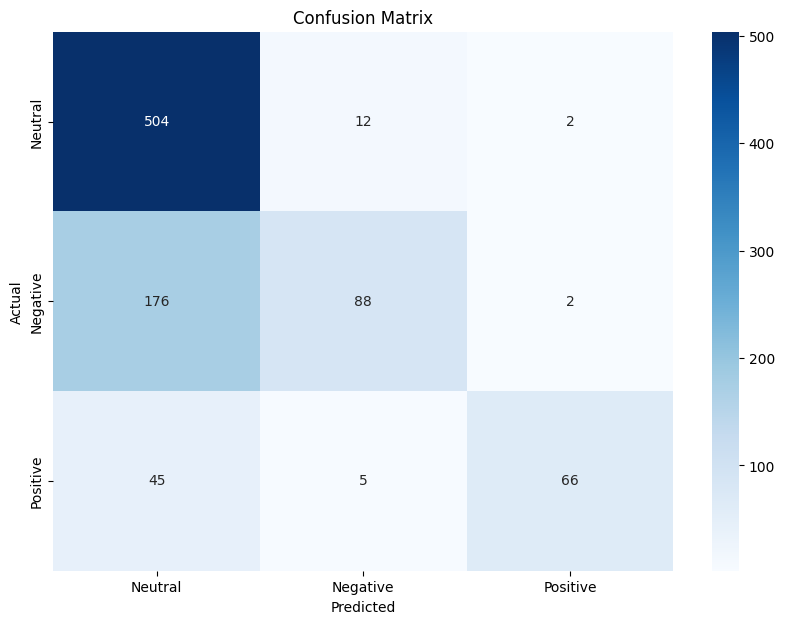

In [16]:
cm_svm = confusion_matrix(y_test, y_pred_tfidf)
plt.figure(figsize=(10,7))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=['Neutral', 'Negative', 'Positive'], yticklabels=['Neutral', 'Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Support Vector Machines

In [17]:
from sklearn.svm import SVC

In [18]:
X = df_relevant["text"]
y = df_relevant["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=rand_seed)

In [19]:
tfidf_vectorizer = TfidfVectorizer()
tfidf_vectorizer.fit(X) # build vocab on the whole labeled dataset
X_train_tfidf = tfidf_vectorizer.transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [20]:
print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(3600, 4074)
(900, 4074)


### Standard Configuration

In [21]:
svm_classifier = SVC(kernel='linear', random_state=rand_seed)
svm_classifier.fit(X_train_tfidf, y_train)

SVC(kernel='linear', random_state=42)

In [22]:
y_pred = svm_classifier.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7622222222222222
              precision    recall  f1-score   support

           0       0.74      0.92      0.82       518
           1       0.79      0.44      0.56       266
           2       0.85      0.81      0.83       116

    accuracy                           0.76       900
   macro avg       0.79      0.72      0.74       900
weighted avg       0.77      0.76      0.75       900



### Gridsearch for hyperparameter tuning

In [23]:
svm_classifier_gridsearch = SVC()

# Define the parameter grid
param_grid = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'], # perhaps our decision boundary is nonlinear
    'C': [0.1, 1, 10, 100], # regularization parameter
    'gamma': [0.001, 0.01, 0.1, 1], 
    'degree': [2, 3], # degree of the polynomial kernel
    'coef0': [0, 0.1, 1], # only for poly and sigmoid kernels, 
}

# Perform Grid Search
grid_search = GridSearchCV(svm_classifier_gridsearch, param_grid, cv=5, scoring='accuracy', verbose=10, n_jobs=-1)
grid_search.fit(X_train_tfidf, y_train)

Fitting 5 folds for each of 384 candidates, totalling 1920 fits


GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'coef0': [0, 0.1, 1],
                         'degree': [2, 3], 'gamma': [0.001, 0.01, 0.1, 1],
                         'kernel': ['linear', 'poly', 'rbf', 'sigmoid']},
             scoring='accuracy', verbose=10)

In [24]:
# best parameters and estimator
best_params = grid_search.best_params_
best_estimator = grid_search.best_estimator_

print("Best Parameters:", best_params)

y_pred_gridsearch = best_estimator.predict(X_test_tfidf)

Best Parameters: {'C': 1, 'coef0': 0, 'degree': 2, 'gamma': 0.001, 'kernel': 'linear'}


In [25]:
print("Accuracy:", accuracy_score(y_test, y_pred_gridsearch))
print(classification_report(y_test, y_pred_gridsearch,target_names=['neutral', 'negative', 'positive']))

Accuracy: 0.7622222222222222
              precision    recall  f1-score   support

     neutral       0.74      0.92      0.82       518
    negative       0.79      0.44      0.56       266
    positive       0.85      0.81      0.83       116

    accuracy                           0.76       900
   macro avg       0.79      0.72      0.74       900
weighted avg       0.77      0.76      0.75       900



Das sind interessante Ergebnisse. die Standard-SVM mit linearer Hyperebene funktioniert wohl am besten. 76% accuracy ist auf den Daten wirklich stark, wenn man bedenkt, dass kein Kontext mit eingeflossen ist, und die Entscheidung zwischen neutral und negativ beim Labeln selbst nicht immer ganz klar war.  
Auch die Precision ist schon gar nicht so schlecht. Positive Sätze werden am besten erkannt. Die waren aber auch beim Labeln immer recht klar unterscheidbar.   
Nur der Recall auf den negativen Daten ist deutlich zu schlecht. Mal sehen, welche Art Samples falsch klassifiziert werden...

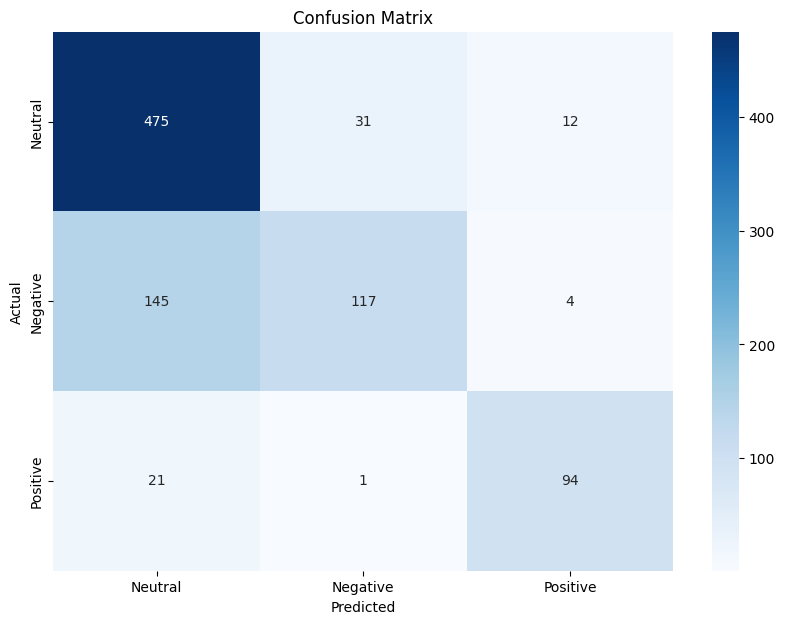

In [26]:
cm_svm_grid = confusion_matrix(y_test, y_pred_gridsearch)
plt.figure(figsize=(10,7))
sns.heatmap(cm_svm_grid, annot=True, fmt='d', cmap='Blues', xticklabels=['Neutral', 'Negative', 'Positive'], yticklabels=['Neutral', 'Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [27]:
actually_negative_wrong_neutral = pd.DataFrame(X_test[(y_test == 1) & (y_pred == 0)])
pd.set_option('display.max_colwidth', None)
actually_negative_wrong_neutral.sample(20)

,text
3679,Respektlos!
2542,Das hätten Sie früher sagen sollen!
3012,Dann macht doch mal was!
4017,"Ich mach mir die Welt, wie sie mir gefällt!"
297,Schön wäre es!
680,"Eine Straße ist nach ihm benannt! Hier um die Ecke! Das tut deinem Hirn gut, wenn da ein bisschen Luft reinkommt, und deinem Bauch auch!"
139,Was ist das denn für ein Eiertanz?
4393,"Jetzt werden Sie auch noch polemisch, Herr Meyer! Das steht Ihnen nicht gut an!"
144,Auch weil die Preise am Markt so hoch sind! Wenn Sie sich mal die Getreidepreise ansehen würden! Aber das tun Sie ja nicht!
3641,"Da bin ich aber gespannt, wie das im Agrarhaushalt gehen soll!"


"Waffen und Morde" wird hier als neutral eingestuft. Man merkt doch, dass hier kein vortrainiertes Sprachmodell oder Embeddings dahinter sind, sondern, dass nur die wirklich im Datensatz vorkommenden Informationen berücksichtigt werden.  
Das hat mich auf den in auch in der Vorlesung kurz besprochenen Ansatz gebracht, ein BERT-Modell als Embedding benutzen könnte.

# BERT-Embeddings x SVM

In [28]:
import torch
from transformers import BertTokenizer, BertModel
device = 'cuda'

In [29]:
tokenizer = BertTokenizer.from_pretrained('bert-base-german-cased')
model = BertModel.from_pretrained('bert-base-german-cased').to(device)

# Function to get BERT embeddings
def get_bert_embeddings(text_list):
    embeddings = []
    for text in text_list:
        inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=512).to(device)
        outputs = model(**inputs)
        last_hidden_states = outputs.last_hidden_state.to('cpu')
        embeddings.append(last_hidden_states.mean(dim=1).detach().numpy().flatten())
    return embeddings

# Get BERT embeddings for train and test sets
X_train_embeddings = get_bert_embeddings(X_train)
X_test_embeddings = get_bert_embeddings(X_test)

c:\ProgFiles\PythonVenvs\nlpvenv2\Lib\site-packages\transformers\models\bert\modeling_bert.py:435: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at ..\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:455.)
  attn_output = torch.nn.functional.scaled_dot_product_attention(


In [30]:
print(np.array(X_test_embeddings).shape)

(900, 768)


In [31]:
# Train an SVM classifier
svm_bert_emb = SVC(kernel='linear')
svm_bert_emb.fit(X_train_embeddings, y_train)

# Predictions
y_pred_svm_bert = svm_bert_emb.predict(X_test_embeddings)


y_pred_svm_bert_txt = [id2label[x] for x in y_pred_svm_bert]

report_svm_bert = classification_report(y_test_txt, y_pred_svm_bert_txt, zero_division=0 )

In [32]:
print(report_svm_bert)

              precision    recall  f1-score   support

    negative       0.66      0.65      0.65       266
     neutral       0.79      0.79      0.79       518
    positive       0.77      0.84      0.80       116

    accuracy                           0.75       900
   macro avg       0.74      0.76      0.75       900
weighted avg       0.75      0.75      0.75       900



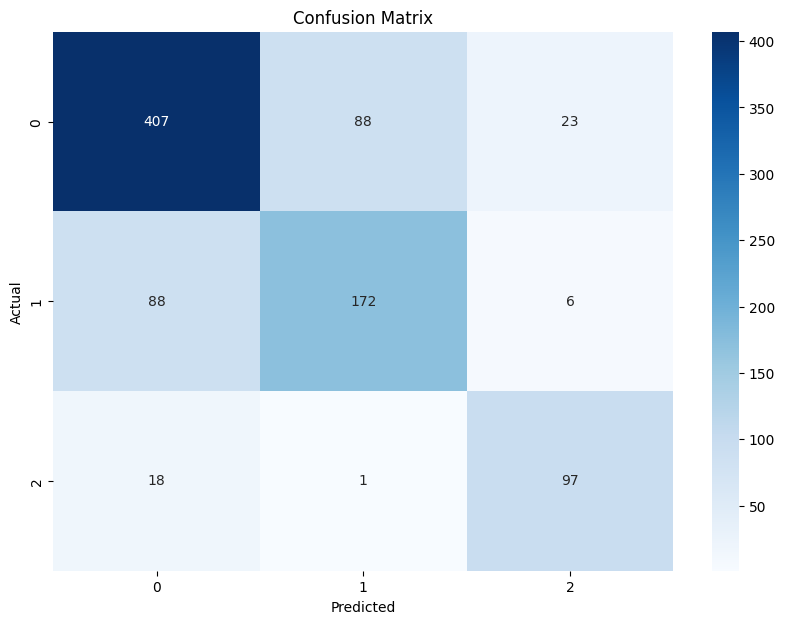

In [33]:
cm_svm_bert = confusion_matrix(y_test_txt, y_pred_svm_bert_txt, labels=['neutral', 'negative', 'positive'])
plt.figure(figsize=(10,7))
sns.heatmap(cm_svm_bert, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Grid search für die SVM mit BERT-Embeddings

Da die Laufzeit hier erheblich höher ist, habe ich die Parameterauswahl etwas eingeschränkt.

In [34]:
svm_bert_emb_gridsearch = SVC()

# Define the parameter grid
param_grid = {
    'kernel': ['linear', 'poly', 'rbf'], # perhaps our decision boundary is nonlinear
    'C': [0.1, 1, 10], # regularization parameter
    'gamma': [0.001, 0.01, 0.1], 
    'degree': [2, 3], # degree of the polynomial kernel
    'coef0': [0, 0.1, 1], # only for poly and sigmoid kernels, 
}

# Perform Grid Search
grid_search = GridSearchCV(svm_bert_emb_gridsearch, param_grid, cv = 2, scoring='accuracy', verbose=10, n_jobs=-1)
grid_search.fit(X_train_embeddings, y_train)

Fitting 2 folds for each of 162 candidates, totalling 324 fits


GridSearchCV(cv=2, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'coef0': [0, 0.1, 1],
                         'degree': [2, 3], 'gamma': [0.001, 0.01, 0.1],
                         'kernel': ['linear', 'poly', 'rbf']},
             scoring='accuracy', verbose=10)

In [36]:
# best parameters and estimator
best_params = grid_search.best_params_ 
svm_bert_emb_gridsearch = grid_search.best_estimator_

print("Best Parameters:", best_params)

y_pred_svm_bert_gridsearch= svm_bert_emb_gridsearch.predict(X_test_embeddings)
y_pred_svm_bert_gridsearch_txt = [id2label[x] for x in y_pred_svm_bert_gridsearch]

Best Parameters: {'C': 1, 'coef0': 0, 'degree': 2, 'gamma': 0.01, 'kernel': 'rbf'}


In [37]:
print(classification_report(y_test, y_pred_gridsearch,target_names=['neutral', 'negative', 'positive']))

              precision    recall  f1-score   support

     neutral       0.74      0.92      0.82       518
    negative       0.79      0.44      0.56       266
    positive       0.85      0.81      0.83       116

    accuracy                           0.76       900
   macro avg       0.79      0.72      0.74       900
weighted avg       0.77      0.76      0.75       900



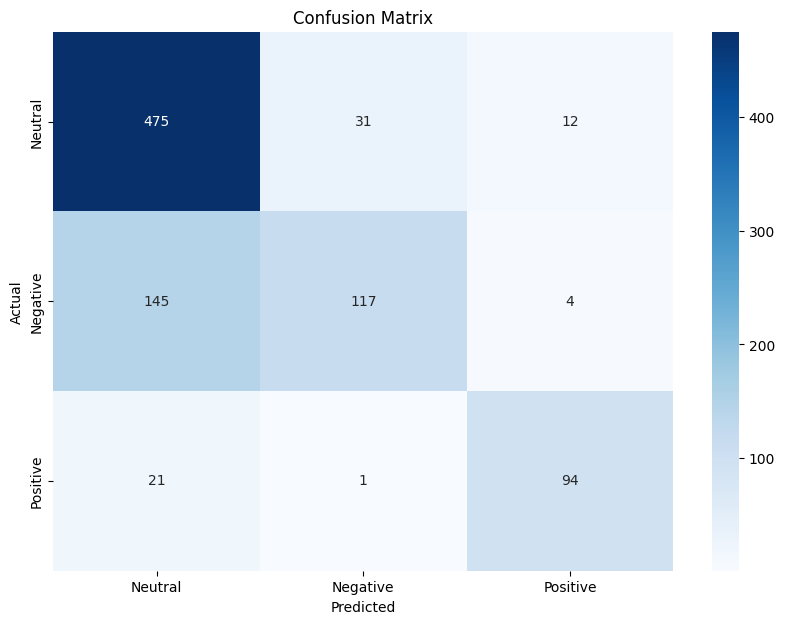

In [40]:
cm_svm_bert_emb_grid = confusion_matrix(y_test_txt, y_pred_svm_bert_gridsearch_txt)
plt.figure(figsize=(10,7))
sns.heatmap(cm_svm_grid, annot=True, fmt='d', cmap='Blues', xticklabels=['Neutral', 'Negative', 'Positive'], yticklabels=['Neutral', 'Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()